In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print('Libraries loaded!')

Libraries loaded!


In [3]:
# ── Data Source: SimilarWeb, StatCounter, First Page Sage, DataReportal ──

quarters = ['Q1 2024','Q2 2024','Q3 2024','Q4 2024',
            'Q1 2025','Q2 2025','Q3 2025','Q4 2025',
            'Q1 2026','Q2 2026']

market_share = pd.DataFrame({
    'Quarter' : quarters,
    'ChatGPT' : [87, 85, 84, 82, 78, 74, 70, 68, 65, 64],
    'Gemini'  : [5,  6,  8,  10, 12, 14, 16, 18, 20, 21],
    'Copilot' : [4,  4,  5,  5,  5,  5,  5,  5,  5,  5],
    'Claude'  : [1,  1.5, 2, 2.2, 2.5, 3, 3, 3.2, 3.5, 4],
    'Others'  : [3,  3.5, 1, 0.8, 2.5, 4, 6, 5.8, 6.5, 6]
})
market_share.set_index('Quarter', inplace=True)

traffic = pd.DataFrame({
    'Month'      : ['Apr 2024','Jul 2024','Oct 2024',
                    'Jan 2025','Mar 2025','Aug 2025'],
    'ChatGPT'    : [3900, 4300, 4600, 4900, 5200, 5840],
    'Copilot'    : [80,   300,  500,  650,  800,  920],
    'Gemini'     : [179,  150,  140,  118,  154,  141],
    'Perplexity' : [8,    9,    11,   12,   13,   12.7]
})
traffic.set_index('Month', inplace=True)

platforms = pd.DataFrame({
    'Platform'           : ['ChatGPT','Gemini','Copilot',
                            'Claude','Perplexity','Grok'],
    'Company'            : ['OpenAI','Google','Microsoft',
                            'Anthropic','Perplexity AI','xAI'],
    'Market_Share_Pct'   : [64.5, 21.5, 5.0, 3.0, 4.0, 2.0],
    'Monthly_Traffic_M'  : [5840, 284, 920, 10, 12.7, 160],
    'YoY_Growth_Pct'     : [100, 370, 1038, 159, 80, 9300],
    'Launch_Year'        : [2022, 2023, 2023, 2023, 2022, 2023]
})

share_change = pd.DataFrame({
    'Tool'    : ['ChatGPT','Gemini','Copilot','Claude','Others'],
    'Q1_2024' : [87, 5, 4, 1, 3],
    'Q2_2026' : [64, 21, 5, 4, 6]
})
share_change['Change'] = share_change['Q2_2026'] - share_change['Q1_2024']
share_change = share_change.sort_values('Change')

print('Dataset created successfully!')
print(f'Market share: {market_share.shape}')
print(f'Traffic data: {traffic.shape}')
print(f'Platforms   : {len(platforms)} tools')
print()
print(market_share)

Dataset created successfully!
Market share: (10, 5)
Traffic data: (6, 4)
Platforms   : 6 tools

         ChatGPT  Gemini  Copilot  Claude  Others
Quarter                                          
Q1 2024       87       5        4     1.0     3.0
Q2 2024       85       6        4     1.5     3.5
Q3 2024       84       8        5     2.0     1.0
Q4 2024       82      10        5     2.2     0.8
Q1 2025       78      12        5     2.5     2.5
Q2 2025       74      14        5     3.0     4.0
Q3 2025       70      16        5     3.0     6.0
Q4 2025       68      18        5     3.2     5.8
Q1 2026       65      20        5     3.5     6.5
Q2 2026       64      21        5     4.0     6.0


In [4]:
print('=== Platform Profiles ===')
print(platforms.to_string(index=False))

print('\n=== Market Share Summary ===')
print(market_share.describe().round(2))

print('\n=== Share Change Q1 2024 → Q2 2026 ===')
print(share_change[['Tool','Q1_2024','Q2_2026','Change']].to_string(index=False))

=== Platform Profiles ===
  Platform       Company  Market_Share_Pct  Monthly_Traffic_M  YoY_Growth_Pct  Launch_Year
   ChatGPT        OpenAI              64.5             5840.0             100         2022
    Gemini        Google              21.5              284.0             370         2023
   Copilot     Microsoft               5.0              920.0            1038         2023
    Claude     Anthropic               3.0               10.0             159         2023
Perplexity Perplexity AI               4.0               12.7              80         2022
      Grok           xAI               2.0              160.0            9300         2023

=== Market Share Summary ===
       ChatGPT  Gemini  Copilot  Claude  Others
count    10.00   10.00    10.00   10.00   10.00
mean     75.70   13.00     4.80    2.59    3.91
std       8.65    5.73     0.42    0.93    2.11
min      64.00    5.00     4.00    1.00    0.80
25%      68.50    8.50     5.00    2.05    2.62
50%      76.00   13

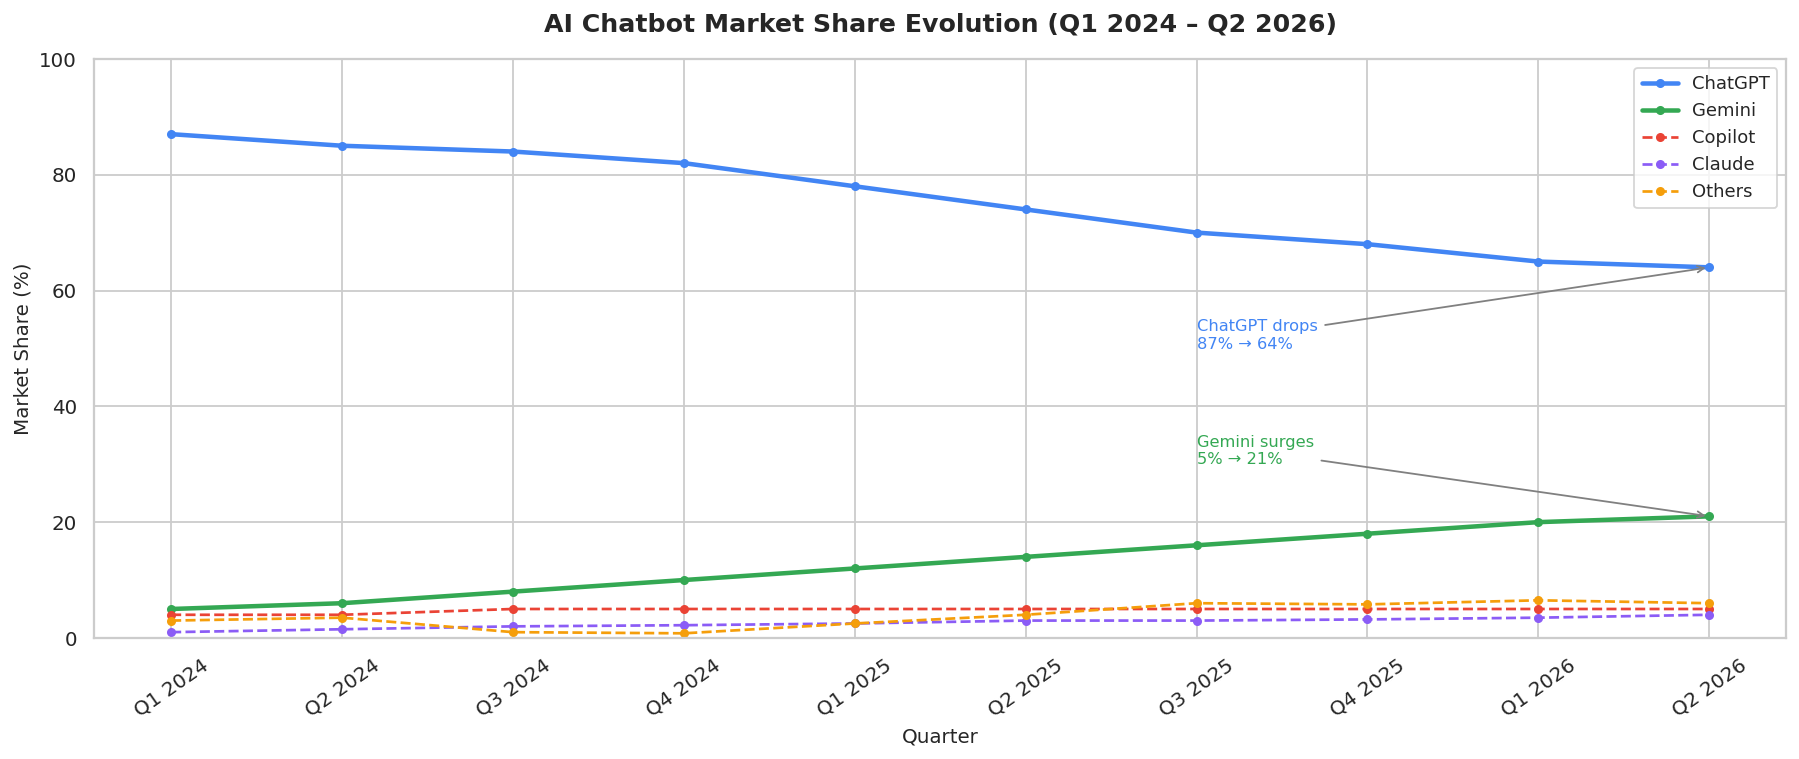

In [17]:
colors = {
    'ChatGPT' : '#4285F4',
    'Gemini'  : '#34A853',
    'Copilot' : '#EA4335',
    'Claude'  : '#8B5CF6',
    'Others'  : '#F59E0B'
}

fig, ax = plt.subplots(figsize=(14, 6))

for col in market_share.columns:
    style = '-' if col in ['ChatGPT', 'Gemini'] else '--'
    lw    = 2.5 if style == '-' else 1.5
    ax.plot(market_share.index, market_share[col],
            label=col, color=colors[col],
            linewidth=lw, linestyle=style,
            marker='o', markersize=4)

ax.set_title('AI Chatbot Market Share Evolution (Q1 2024 – Q2 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Market Share (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='upper right', fontsize=10)

ax.annotate('ChatGPT drops\n87% → 64%',
            xy=('Q2 2026', 64), xytext=('Q3 2025', 50),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='#4285F4')

ax.annotate('Gemini surges\n5% → 21%',
            xy=('Q2 2026', 21), xytext=('Q3 2025', 30),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='#34A853')

plt.tight_layout()
plt.savefig('chart1_market_share_trend.png', bbox_inches='tight')
plt.show()

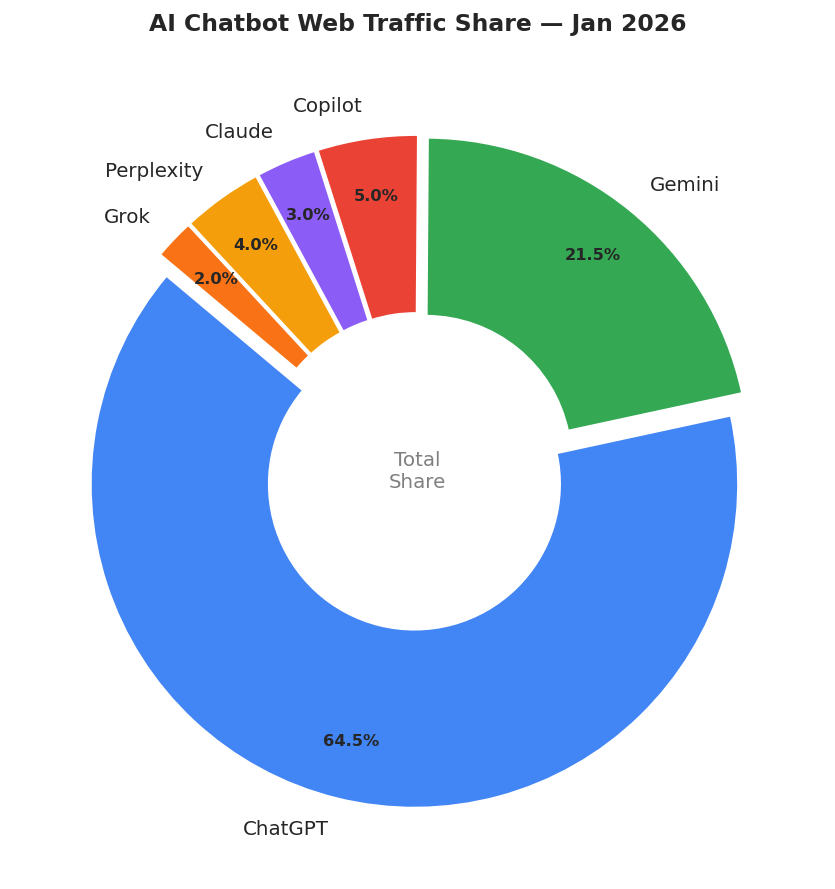

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

labels  = platforms['Platform'].tolist()
sizes   = platforms['Market_Share_Pct'].tolist()
palette = ['#4285F4','#34A853','#EA4335','#8B5CF6','#F59E0B','#F97316']
explode = [0.04] * len(labels)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=palette,
    autopct='%1.1f%%', startangle=140,
    explode=explode, pctdistance=0.82,
    wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title('AI Chatbot Web Traffic Share — Jan 2026',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0, 0, 'Total\nShare', ha='center', va='center',
        fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('chart2_donut.png', bbox_inches='tight')
plt.show()

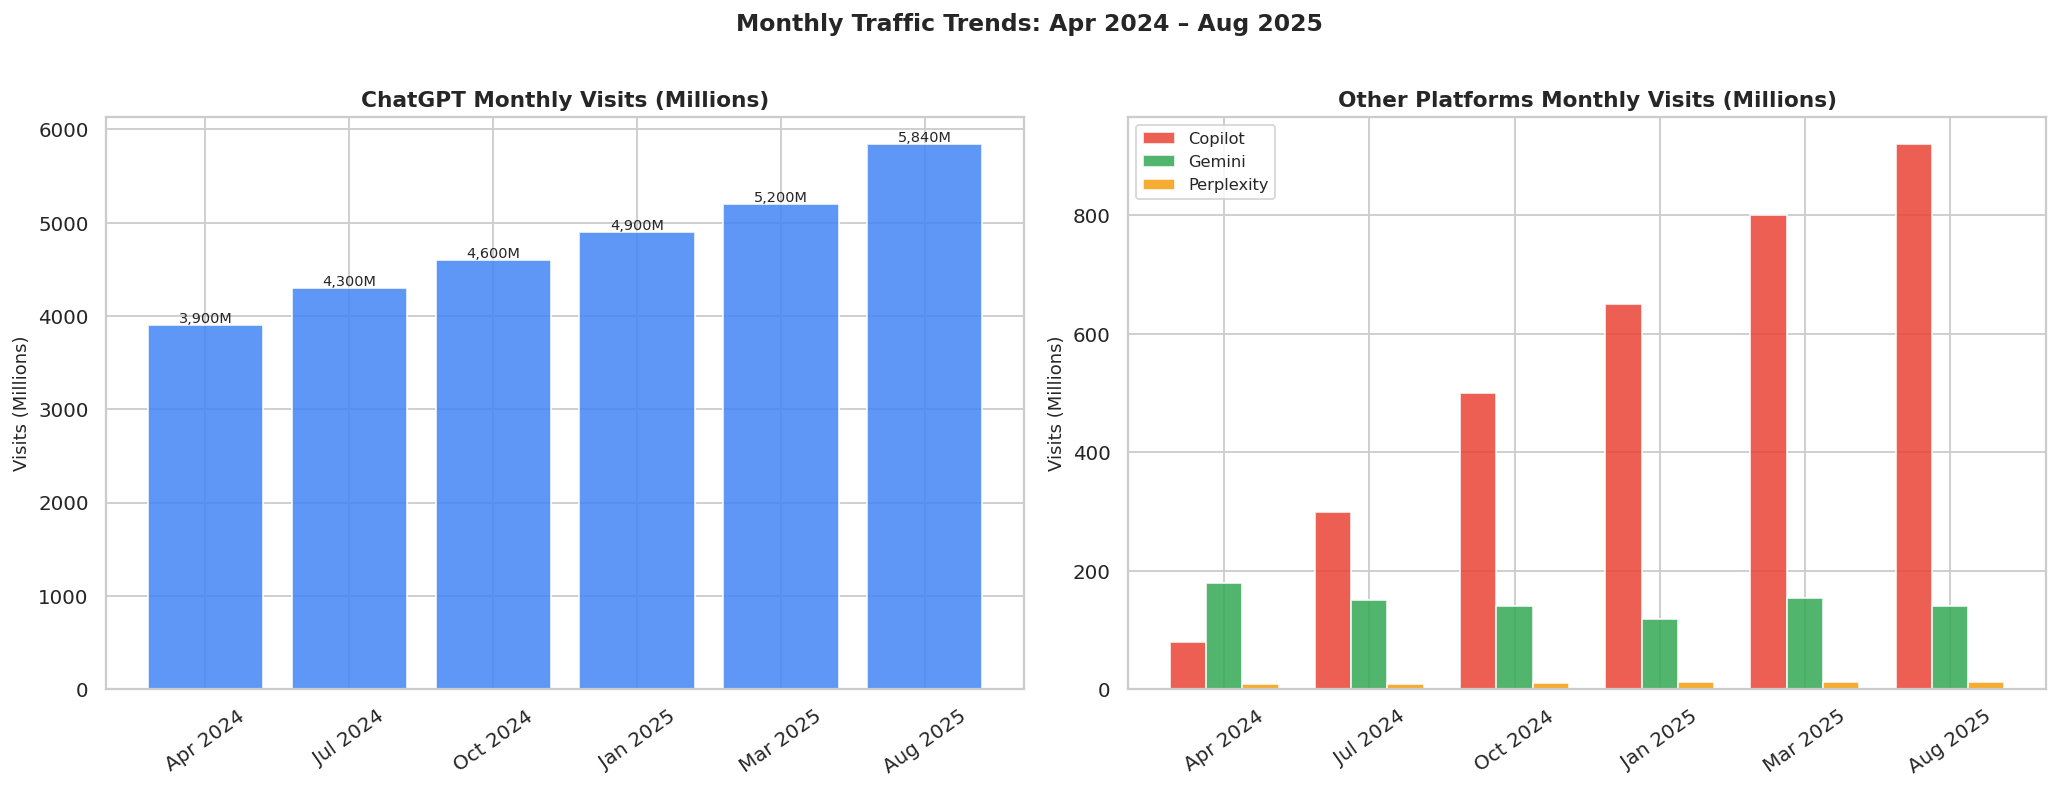

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — ChatGPT alone
axes[0].bar(traffic.index, traffic['ChatGPT'],
            color='#4285F4', alpha=0.85, edgecolor='white')
axes[0].set_title('ChatGPT Monthly Visits (Millions)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Visits (Millions)', fontsize=10)
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(traffic['ChatGPT']):
    axes[0].text(i, v + 30, f'{v:,.0f}M',
                 ha='center', fontsize=8)

# Right — Others
x = np.arange(len(traffic.index))
w = 0.25
for i, (col, c) in enumerate(zip(
        ['Copilot','Gemini','Perplexity'],
        ['#EA4335','#34A853','#F59E0B'])):
    axes[1].bar(x + i*w, traffic[col], width=w,
                label=col, color=c, alpha=0.85, edgecolor='white')

axes[1].set_title('Other Platforms Monthly Visits (Millions)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Visits (Millions)', fontsize=10)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(traffic.index, rotation=35)
axes[1].legend(fontsize=9)

plt.suptitle('Monthly Traffic Trends: Apr 2024 – Aug 2025',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart3_traffic.png', bbox_inches='tight')
plt.show()

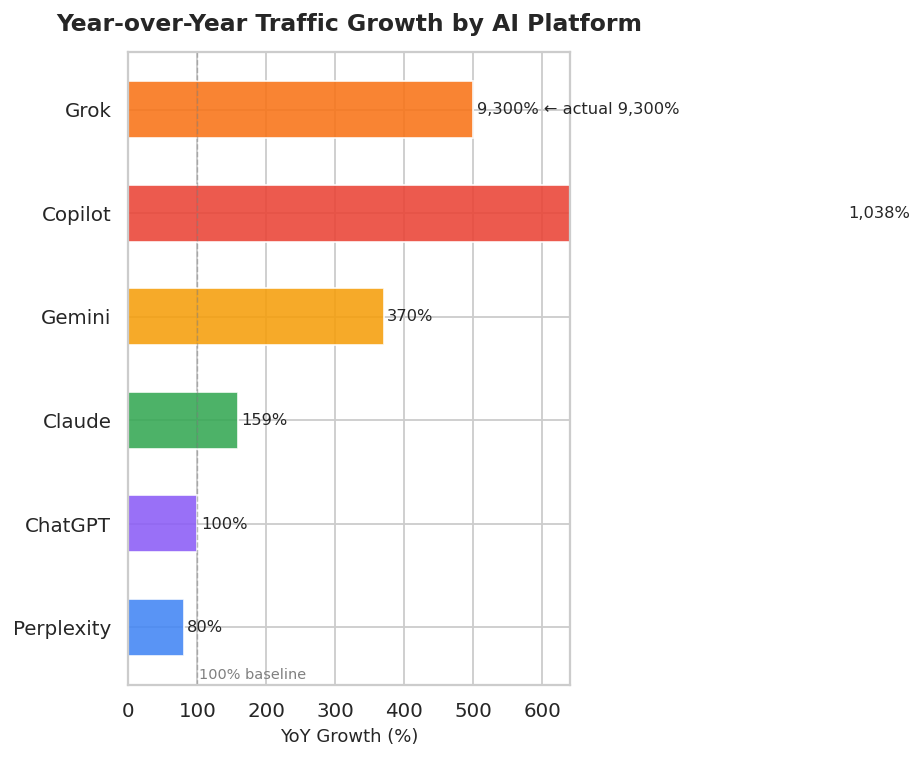

In [12]:
growth_df   = platforms[['Platform','YoY_Growth_Pct']]\
              .sort_values('YoY_Growth_Pct', ascending=True)
growth_plot = growth_df.copy()
growth_plot.loc[growth_plot['Platform']=='Grok',
                'YoY_Growth_Pct'] = 500  # capped for visual

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4285F4','#8B5CF6','#34A853',
              '#F59E0B','#EA4335','#F97316']

bars = ax.barh(growth_plot['Platform'],
               growth_plot['YoY_Growth_Pct'],
               color=bar_colors, alpha=0.88,
               edgecolor='white', height=0.55)

for bar, (_, row) in zip(bars, growth_df.iterrows()):
    actual = row['YoY_Growth_Pct']
    note   = ' ← actual 9,300%' if actual == 9300 else ''
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f'{actual:,}%{note}', va='center', fontsize=9)

ax.set_title('Year-over-Year Traffic Growth by AI Platform',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('YoY Growth (%)', fontsize=10)
ax.set_xlim(0, 640)
ax.axvline(100, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.5)
ax.text(102, -0.5, '100% baseline', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('chart4_yoy_growth.png', bbox_inches='tight')
plt.show()

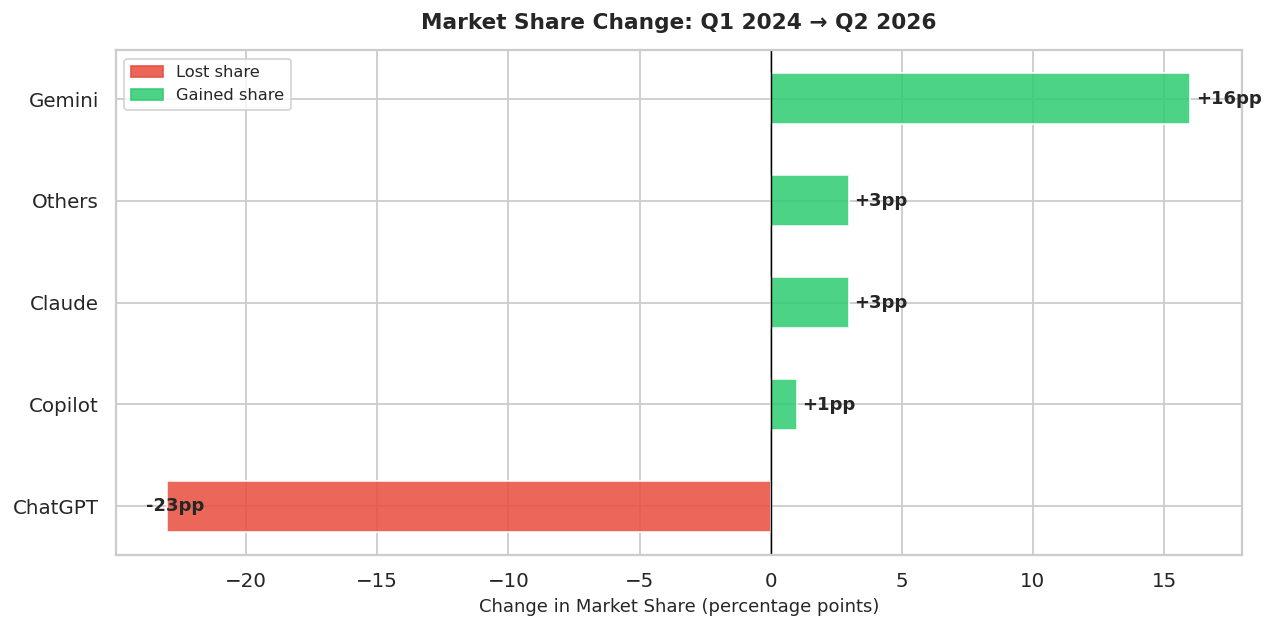

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_c = ['#E74C3C' if v < 0 else '#2ECC71'
         for v in share_change['Change']]

bars = ax.barh(share_change['Tool'], share_change['Change'],
               color=bar_c, alpha=0.85,
               edgecolor='white', height=0.5)

for bar, val in zip(bars, share_change['Change']):
    x_pos = bar.get_width() - 0.8 if val < 0 \
            else bar.get_width() + 0.2
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+}pp', va='center',
            fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Market Share Change: Q1 2024 → Q2 2026',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Change in Market Share (percentage points)',
              fontsize=10)

lost   = mpatches.Patch(color='#E74C3C', alpha=0.85, label='Lost share')
gained = mpatches.Patch(color='#2ECC71', alpha=0.85, label='Gained share')
ax.legend(handles=[lost, gained], fontsize=9)

plt.tight_layout()
plt.savefig('chart5_share_change.png', bbox_inches='tight')
plt.show()

In [14]:
print('=' * 55)
print('    AI TOOLS TREND ANALYSIS — KEY INSIGHTS')
print('=' * 55)

s = market_share.loc['Q1 2024','ChatGPT']
e = market_share.loc['Q2 2026','ChatGPT']
print(f'\n1. ChatGPT lost {s-e:.0f}pp share → {s}% to {e}%')

gs = market_share.loc['Q1 2024','Gemini']
ge = market_share.loc['Q2 2026','Gemini']
print(f'2. Gemini gained {ge-gs:.0f}pp share → {gs}% to {ge}%')

top = platforms.loc[platforms['Monthly_Traffic_M'].idxmax()]
print(f'3. Traffic leader: {top.Platform} '
      f'at {top.Monthly_Traffic_M:,.0f}M visits/month')

print('4. Claude: 3% traffic but 159% revenue growth')
print('   $850M (2024) → $2.2B projected (2025)')
print('5. Grok: 9,300% YoY — fastest AI platform entry ever')
print('6. Copilot: 1,038% traffic growth but only 5% share')
print('   Microsoft $13B investment ≠ consumer dominance')
print('\n' + '=' * 55)
print('=' * 55)

    AI TOOLS TREND ANALYSIS — KEY INSIGHTS

1. ChatGPT lost 23pp share → 87% to 64%
2. Gemini gained 16pp share → 5% to 21%
3. Traffic leader: ChatGPT at 5,840M visits/month
4. Claude: 3% traffic but 159% revenue growth
   $850M (2024) → $2.2B projected (2025)
5. Grok: 9,300% YoY — fastest AI platform entry ever
6. Copilot: 1,038% traffic growth but only 5% share
   Microsoft $13B investment ≠ consumer dominance

